# Affordability Metric 

This notebook calculates affordability scores for Pittsburgh neighborhoods using property assessment values.



In [9]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

## Step 2: Load the properties

In [10]:
properties = pd.read_csv('data/property_assessments.csv', low_memory=False)

print('Rows:', len(properties))
print(properties.columns.tolist())
properties.head()

Rows: 584896
['PARID', 'PROPERTYHOUSENUM', 'PROPERTYFRACTION', 'PROPERTYADDRESS', 'PROPERTYCITY', 'PROPERTYSTATE', 'PROPERTYUNIT', 'PROPERTYZIP', 'MUNICODE', 'MUNIDESC', 'SCHOOLCODE', 'SCHOOLDESC', 'LEGAL1', 'LEGAL2', 'LEGAL3', 'NEIGHCODE', 'NEIGHDESC', 'TAXCODE', 'TAXDESC', 'TAXSUBCODE', 'TAXSUBCODE_DESC', 'OWNERCODE', 'OWNERDESC', 'CLASS', 'CLASSDESC', 'USECODE', 'USEDESC', 'LOTAREA', 'HOMESTEADFLAG', 'FARMSTEADFLAG', 'CLEANGREEN', 'ABATEMENTFLAG', 'RECORDDATE', 'SALEDATE', 'SALEPRICE', 'SALECODE', 'SALEDESC', 'DEEDBOOK', 'DEEDPAGE', 'PREVSALEDATE', 'PREVSALEPRICE', 'PREVSALEDATE2', 'PREVSALEPRICE2', 'CHANGENOTICEADDRESS1', 'CHANGENOTICEADDRESS2', 'CHANGENOTICEADDRESS3', 'CHANGENOTICEADDRESS4', 'COUNTYBUILDING', 'COUNTYLAND', 'COUNTYTOTAL', 'COUNTYEXEMPTBLDG', 'LOCALBUILDING', 'LOCALLAND', 'LOCALTOTAL', 'FAIRMARKETBUILDING', 'FAIRMARKETLAND', 'FAIRMARKETTOTAL', 'STYLE', 'STYLEDESC', 'STORIES', 'YEARBLT', 'EXTERIORFINISH', 'EXTFINISH_DESC', 'ROOF', 'ROOFDESC', 'BASEMENT', 'BASEMENTDES

,PARID,PROPERTYHOUSENUM,PROPERTYFRACTION,PROPERTYADDRESS,PROPERTYCITY,PROPERTYSTATE,PROPERTYUNIT,PROPERTYZIP,MUNICODE,MUNIDESC,...,HALFBATHS,HEATINGCOOLING,HEATINGCOOLINGDESC,FIREPLACES,BSMTGARAGE,FINISHEDLIVINGAREA,CARDNUMBER,ALT_ID,TAXYEAR,ASOFDATE
0,0001D00125000000,100.0,,5TH AVE,PITTSBURGH,PA,,15222.0,101,1st Ward - PITTSBURGH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,01-APR-26
1,0001D00127000000,23.0,,MARKET SQ,PITTSBURGH,PA,,15222.0,101,1st Ward - PITTSBURGH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,01-APR-26
2,0001D00128000000,24.0,,MARKET SQ,PITTSBURGH,PA,,15222.0,101,1st Ward - PITTSBURGH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,01-APR-26
3,0001D00130000000,26.0,,MARKET SQ,PITTSBURGH,PA,,15222.0,101,1st Ward - PITTSBURGH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,01-APR-26
4,0001D00132000000,115.0,-119,FORBES AVE,PITTSBURGH,PA,,15222.0,101,1st Ward - PITTSBURGH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,01-APR-26


## Step 3: Filter to Pittsburgh Properties

In [11]:
muni_ok = properties['MUNIDESC'].astype(str).str.upper().str.contains('PITTSBURGH', na=False)
class_ok = properties['CLASSDESC'].astype(str).str.upper().eq('RESIDENTIAL')

pgh = properties[muni_ok & class_ok].copy()

pgh['FAIRMARKETTOTAL'] = pd.to_numeric(pgh['FAIRMARKETTOTAL'], errors='coerce')

pgh = pgh[pgh['FAIRMARKETTOTAL'].notna()]
pgh = pgh[pgh['FAIRMARKETTOTAL'] > 0]

print('Rows after filtering:', len(pgh))

Rows after filtering: 119340


## Step 4: Calculate median value by neighborhood

In [12]:
median_values = pgh.groupby('NEIGHDESC')['FAIRMARKETTOTAL'].median().reset_index()
median_values = median_values.rename(columns={'NEIGHDESC': 'neighborhood', 'FAIRMARKETTOTAL': 'median_property_value'})

median_values.head()

,neighborhood,median_property_value
0,1000 GRANDVIEW,340400.0
1,10401,474500.0
2,10402,53400.0
3,10403,80000.0
4,10404,3000.0


## Step 5: Make affordibility Score

In [13]:

lowest = median_values['median_property_value'].min()
highest = median_values['median_property_value'].max()
spread = highest - lowest

if spread == 0:
    median_values['affordability_score'] = 1.0
else:
    median_values['affordability_score'] = 1 - ((median_values['median_property_value'] - lowest) / spread)

affordability_scores = median_values[['neighborhood', 'affordability_score']].sort_values('affordability_score', ascending=False)
affordability_scores.head(10)

,neighborhood,affordability_score
76,CLOVERLEAF MOBILE H.P.,1.000000
90,JONES MOBILE H.P.,0.999062
4,10404,0.998660
113,ROSENBERRY MOBILE H.P.,0.996918
22,11203,0.996382
100,NOBLESTOWN MOBILE H.P.,0.993167
24,11303,0.991023
31,11503,0.984860
21,11202,0.980840
105,PITTSBURGH URBAN,0.980170


## Step 6: Graph

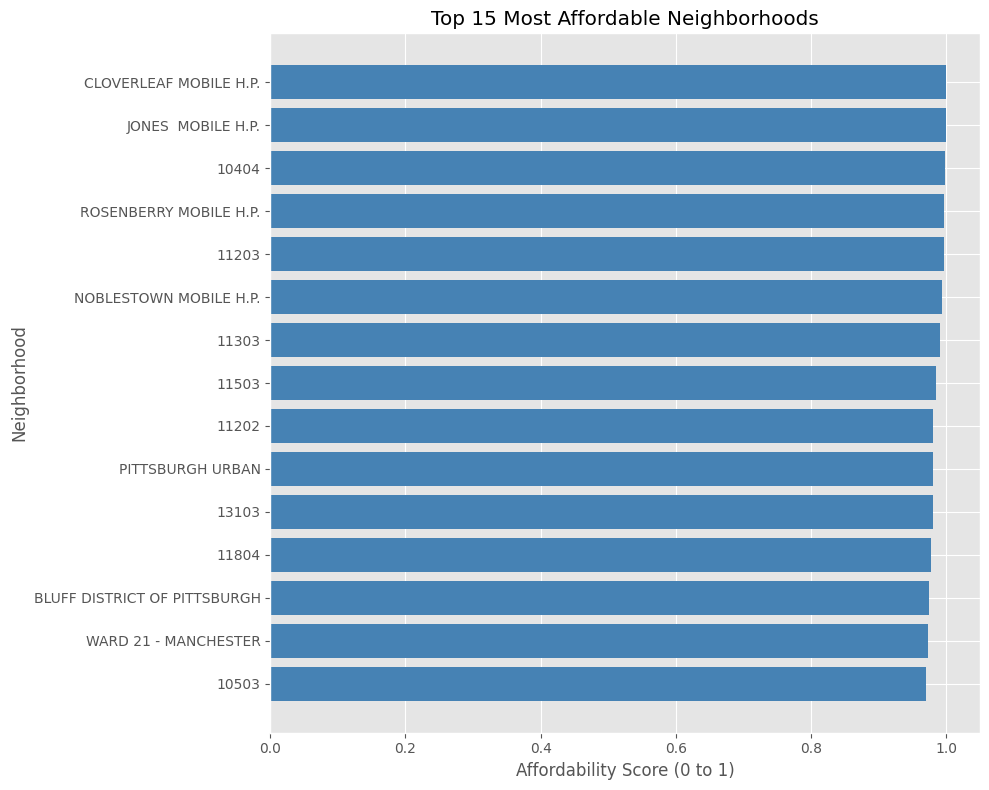

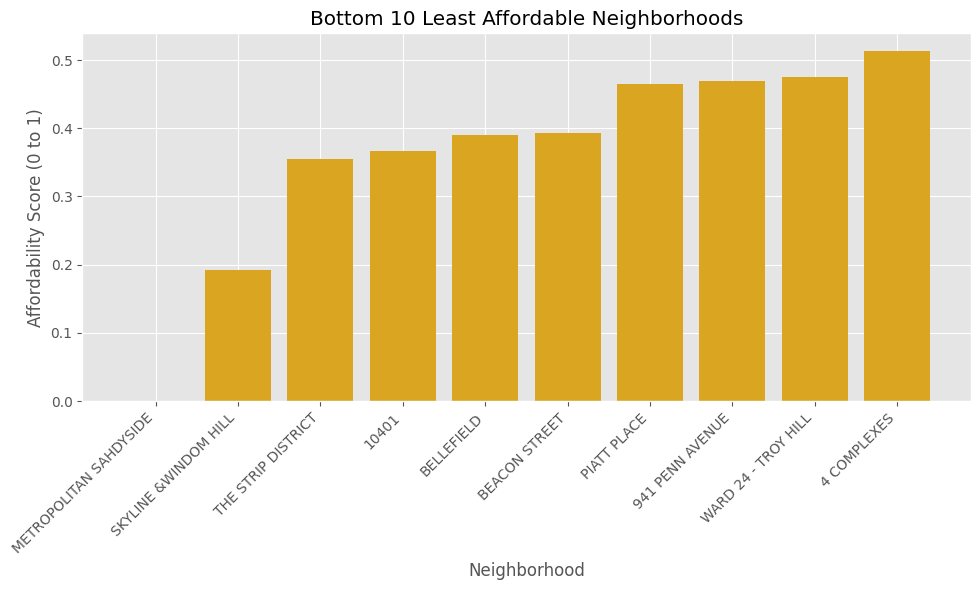

In [ ]:
top_affordable = affordability_scores.head(15).sort_values(by='affordability_score', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_affordable['neighborhood'], top_affordable['affordability_score'], color='steelblue')
plt.xlabel('Affordability Score (0 to 1)')
plt.ylabel('Neighborhood')
plt.title('Top 15 Most Affordable Neighborhoods')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

least_affordable = affordability_scores.sort_values(by='affordability_score', ascending=True).head(10)
least_affordable = least_affordable.sort_values(by='affordability_score', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(least_affordable['neighborhood'], least_affordable['affordability_score'], color='goldenrod')
plt.xlabel('Affordability Score (0 to 1)')
plt.ylabel('Neighborhood')
plt.title('Bottom 10 Least Affordable Neighborhoods')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In conclusion, the least affordable neighborhood is in Squirrel Hill and the most affordable neighborhood is in Overbrook. In the original dataset, the data was organized by neighborhood, but instead of the actual neighborhoods, it put neighborhood codes for many of them, so I had to manually find out what each code meant. This made finding the final conclusion slightly inconvenient but it was not difficult to find the location of these neighborhoods. What I had to do was look at the neighborhood codes that were listed in the dataset and then look at the street address they were located on, and research what neighborhood those streed addresses corresponded to. 
